In [1]:
from typing import Any, Optional

from arcengine import FrameDataRaw

from arc import MyArcSession
from arc_agi import OperationMode
from arc_agi import Arcade
import logging
import numpy as np
from dotenv import load_dotenv
from PIL import Image
from sandbox import SandboxOrchestrator
from google.genai import types
from google import genai
from tools import TOOL_LIST, SYSTEM_PROMPT, TAKE_ACTION
from agent import JackAgent

load_dotenv()


PALETTE = np.array(
    [
        [0xFF, 0xFF, 0xFF],
        [0xCC, 0xCC, 0xCC],
        [0x99, 0x99, 0x99],
        [0x66, 0x66, 0x66],
        [0x33, 0x33, 0x33],
        [0x00, 0x00, 0x00],
        [0xE5, 0x3A, 0xA3],
        [0xFF, 0x7B, 0xCC],
        [0xF9, 0x3C, 0x31],
        [0x1E, 0x93, 0xFF],
        [0x88, 0xD8, 0xF1],
        [0xFF, 0xDC, 0x00],
        [0xFF, 0x85, 0x1B],
        [0x92, 0x12, 0x31],
        [0x4F, 0xCC, 0x30],
        [0xA3, 0x56, 0xD6],
    ],
    dtype=np.uint8,
)


def render_frame(frame: np.ndarray) -> Image.Image:
    rgb = PALETTE[np.clip(np.asarray(frame, dtype=np.uint8), 0, 15)]
    return Image.fromarray(rgb).resize((512, 512), Image.NEAREST)


logger = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s %(message)s", datefmt="%H:%M:%S"
)


def current_state_prompt(obs: FrameDataRaw) -> str:
    return f"""Currently playing game: {obs.game_id}. On level #{obs.levels_completed} out of #{obs.win_levels}.

"""


def starting_state_prompt(obs: FrameDataRaw) -> str:
    res = f"""Starting the following game: {obs.game_id}

"""

    return (
        f"New game started. Initial state:\n{json.dumps(obs, indent=2)}\n\n"
        f"The full grid is in /home/agent/state.json. "
        f"Start by calling render_board to see the board, then take actions to explore."
    )

In [2]:

arcade = Arcade(operation_mode=OperationMode("normal"))
scorecard_id: str = arcade.open_scorecard(tags=["jackagent"])
arc_session = MyArcSession(
    game_id=["ls20", "ft09"][0], arcade=arcade, scorecard_id=scorecard_id
)
sbx = SandboxOrchestrator()
print(sbx.bash("echo sandbox ready"))

agent = JackAgent(sbx=sbx, arc_session=arc_session)


agent.contents = []

2026-04-13 02:03:09 | INFO | Successfully fetched 25 environment(s) from API


02:03:09 Successfully fetched 25 environment(s) from API


2026-04-13 02:03:09 | INFO | Created new scorecard: f1ef20ca-fe1e-4f25-a628-5a5e8d16a465


02:03:09 Created new scorecard: f1ef20ca-fe1e-4f25-a628-5a5e8d16a465


2026-04-13 02:03:09 | INFO | Successfully fetched metadata for game ls20


...

2026-04-13 02:03:09 | INFO | Recording to recordings/f1ef20ca-fe1e-4f25-a628-5a5e8d16a465/ls20-9607627b-20a5b55e-b1e2-4c1a-bf80-18774e1e8825.jsonl


02:03:09 Recording to recordings/f1ef20ca-fe1e-4f25-a628-5a5e8d16a465/ls20-9607627b-20a5b55e-b1e2-4c1a-bf80-18774e1e8825.jsonl


2026-04-13 02:03:09 | INFO | Successfully loaded game class Ls20 from environment_files/ls20/9607627b/ls20.py


02:03:09 Successfully loaded game class Ls20 from environment_files/ls20/9607627b/ls20.py


sandbox ready


02:03:18 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


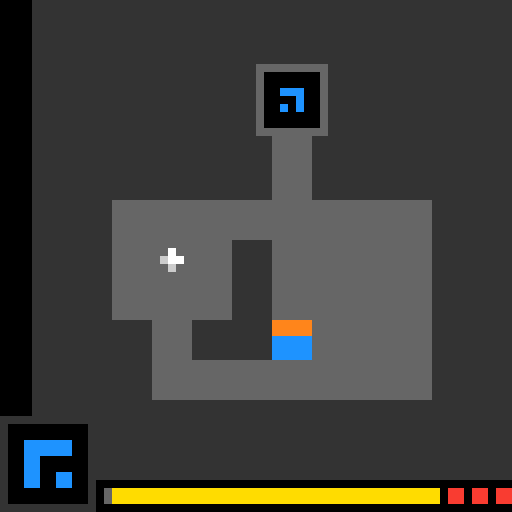

02:03:21 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


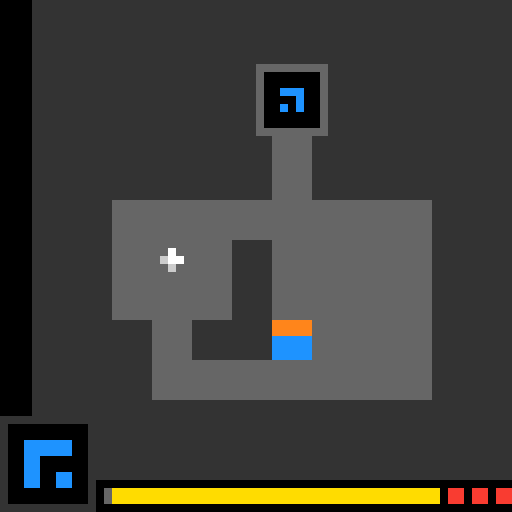

02:03:24 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


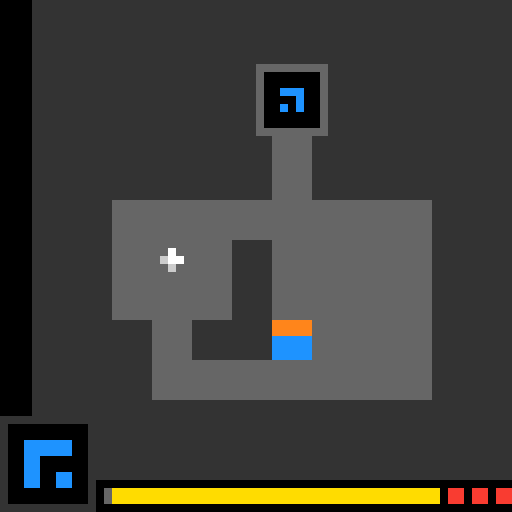

02:03:27 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


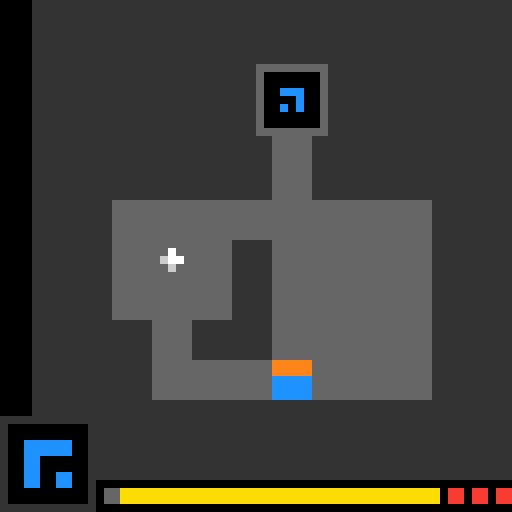

02:03:31 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


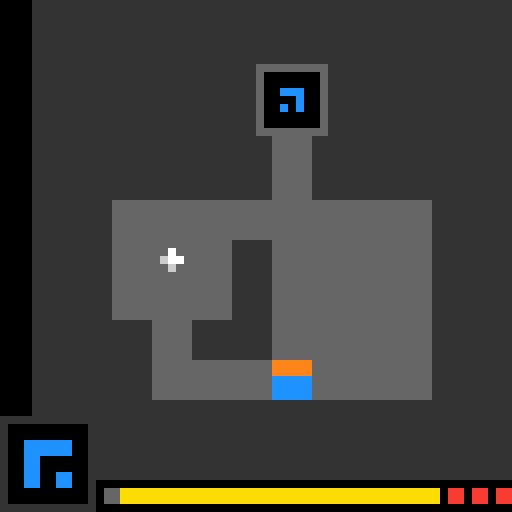

02:03:34 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


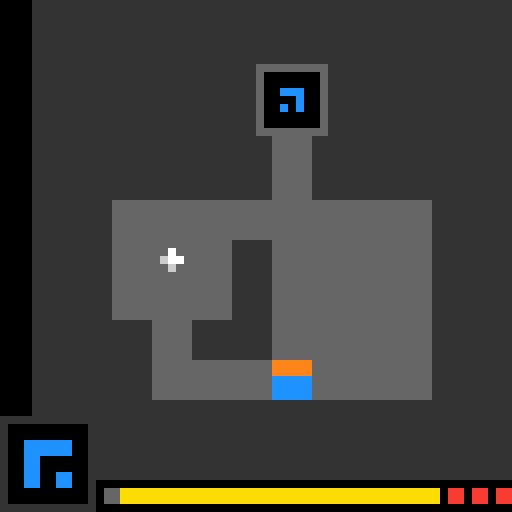

02:03:39 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


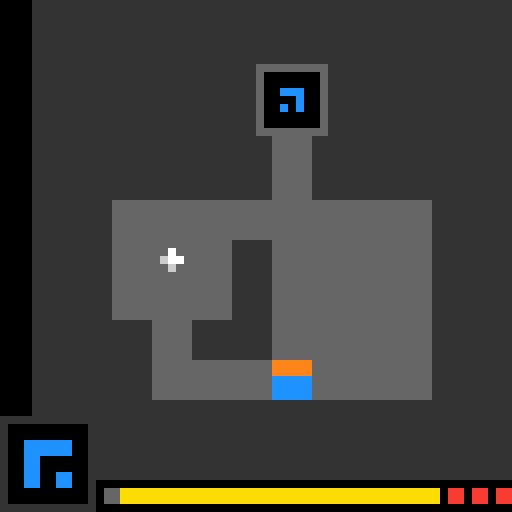

02:03:44 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


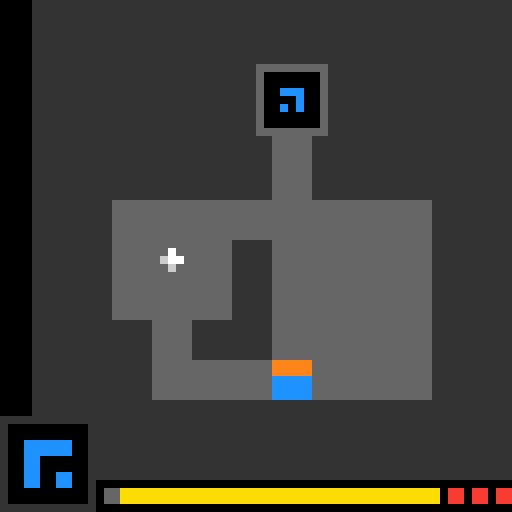

02:03:51 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


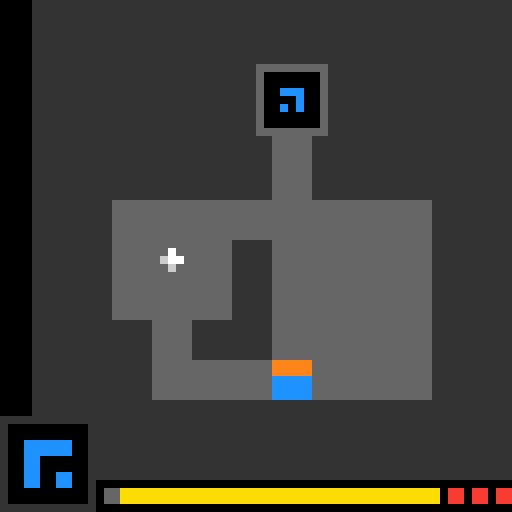

02:03:57 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


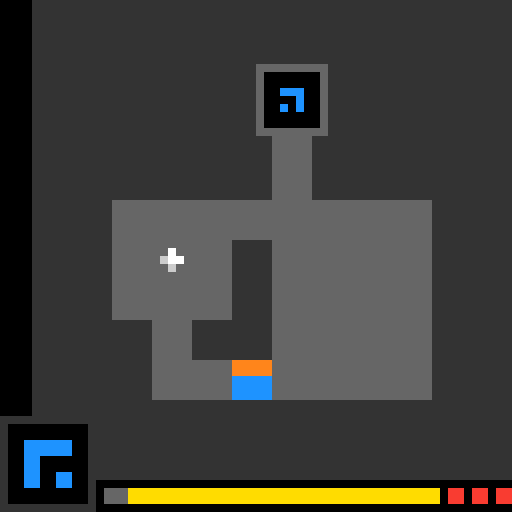

02:04:02 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


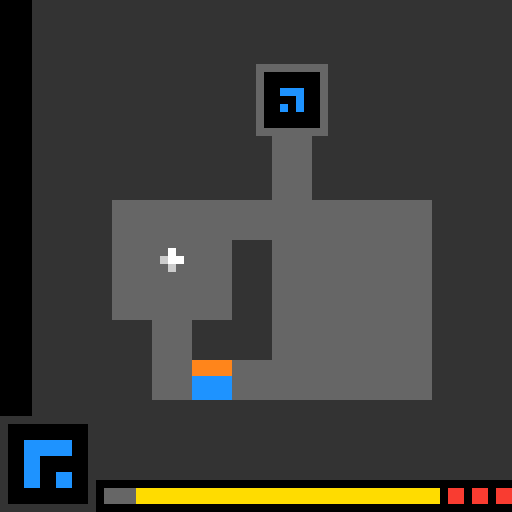

02:04:07 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


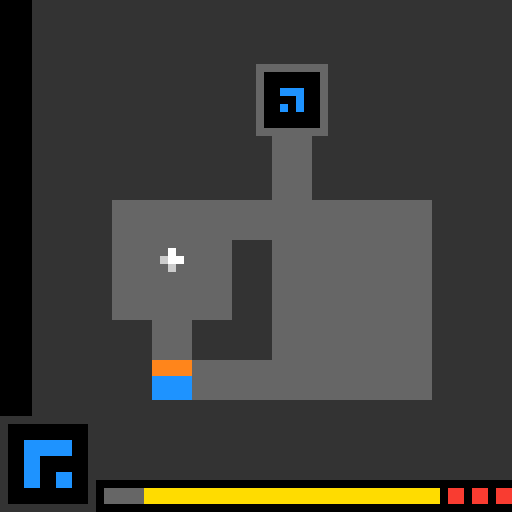

02:04:11 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


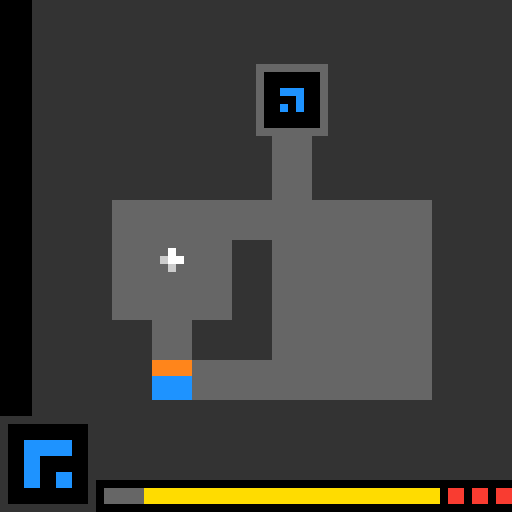

02:04:19 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


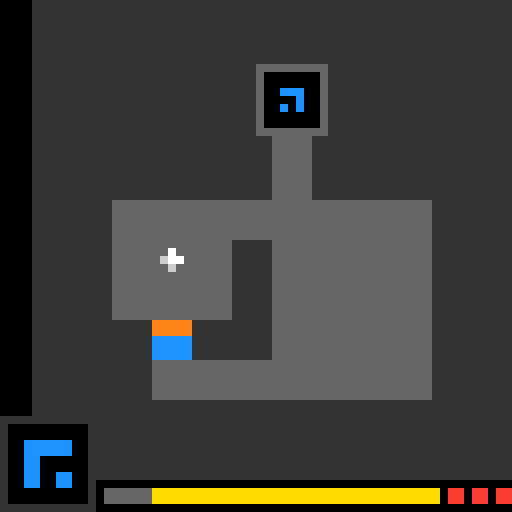

02:04:24 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


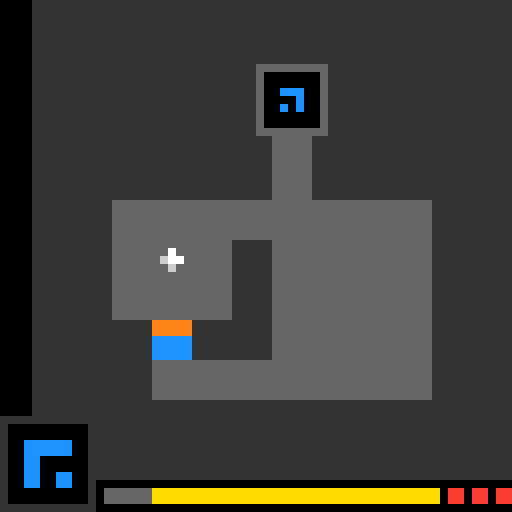

02:04:29 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


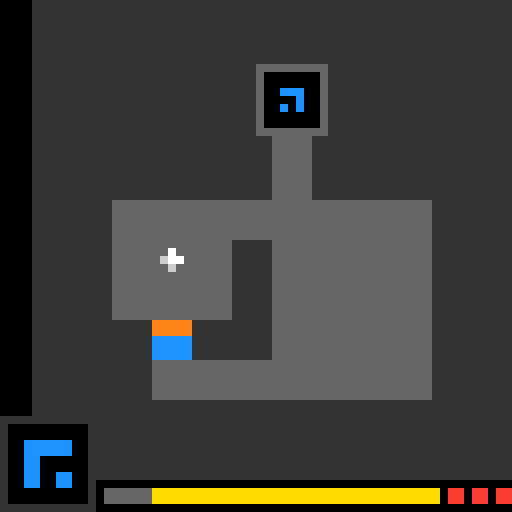

02:04:34 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


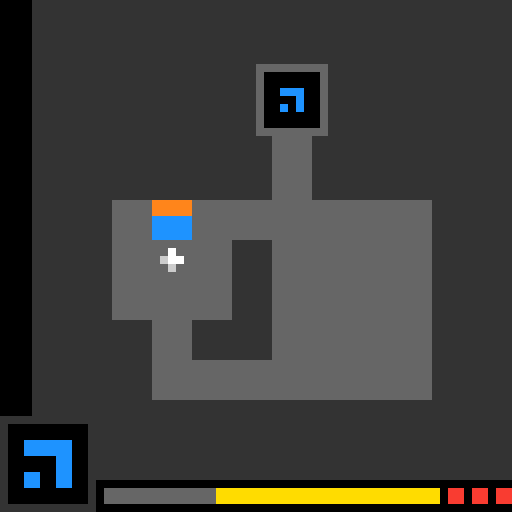

02:04:38 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


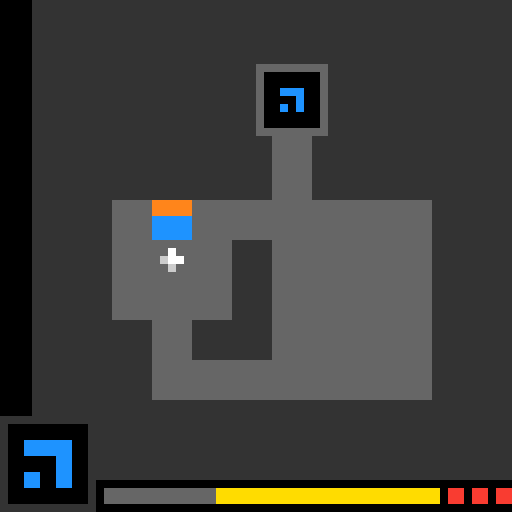

02:04:42 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


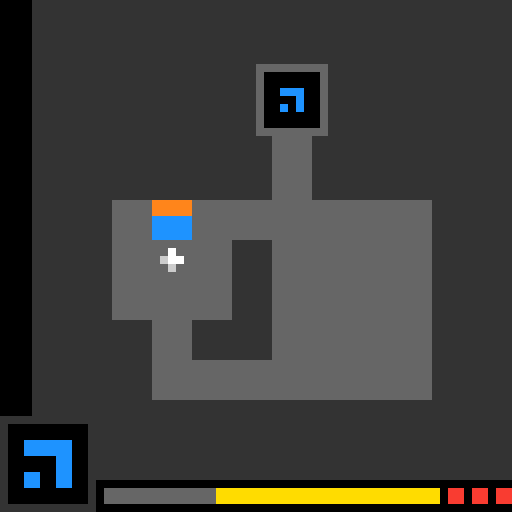

02:04:50 HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-pro-preview:generateContent "HTTP/1.1 200 OK"


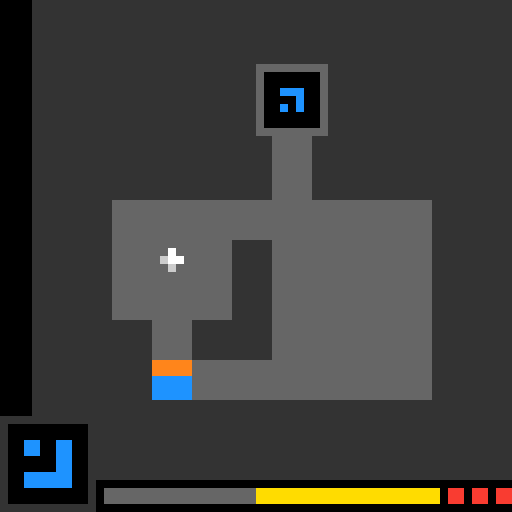

In [ ]:
agent.contents = [
    types.Content(role="user", parts=[types.Part(
        text=f"This is the current board. {arc_session.obs}")])
]

agent.contents.append(types.Content(role="user", parts=[
                      types.Part(text="solve quickly")]))

for _ in range(100):
    agent.generate_response()
    display(render_frame(agent.arc_session.obs.frame[-1]))

In [4]:
agent.contents

[Content(
   parts=[
     Part(
       text="""This is the current board. {
   "game_id": "ls20-9607627b",
   "state": "NOT_FINISHED",
   "levels_completed": 0,
   "win_levels": 7,
   "action_input": {
     "id": 0,
     "data": {},
     "reasoning": null
   },
   "guid": "20a5b55e-b1e2-4c1a-bf80-18774e1e8825",
   "full_reset": true,
   "available_actions": [
     1,
     2,
     3,
     4
   ]
 }"""
     ),
   ],
   role='user'
 ),
 Content(
   parts=[
     Part(
       text='solve quickly'
     ),
   ],
   role='user'
 ),
 Content(
   parts=[
     Part(
       function_call=FunctionCall(
         args={
           'action': 'ACTION1'
         },
         id='dnadd6eb',
         name='take_action'
       ),
       thought_signature=b"\x12\xc1\x01\n\xbe\x01\x01\xbe>\xf6\xfb\xc8\xb8\x9e\r\xa6[\xa1\x1c\xe5\x1dH\xb8[bA\xf8;\xe0\xaf\xef\xa3G\xe6n\x12\x9a\xf9\x04\xd5tv\xb8xMn\x90F'\xcd22\xd3\x0f\x94^]\xb4\xb8]7a\xba=\x9d\x0f\xceq3\xc9NJA#\xda\xa2\x8c\x8b\xcfg\xb6\xcfe\xc9]\xcc\xb5\xaaT\xb8\